In [2]:
import healpy as hp 
import numpy as np
import matplotlib.pyplot as plt



In [3]:
from astropy.io import fits
fits_image_filename = 'maps/LFI_SkyMap_070-BPassCorrected-field-IQU_1024_R3.00_full.fits'

with fits.open(fits_image_filename) as hdul:
    hdul.info()
    print("\n")
    hdr = hdul[0].header
    print("Header: \n")
    print(hdr)

Filename: maps/LFI_SkyMap_070-BPassCorrected-field-IQU_1024_R3.00_full.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  FREQ-MAP-BPCorr    1 BinTableHDU     64   12582912R x 3C   [E, E, E]   


Header: 

SIMPLE  =                    T /Dummy Created by MWRFITS v1.6a                  BITPIX  =                    8 /Dummy primary header created by MWRFITS         NAXIS   =                    0 /No data is associated with this header          EXTEND  =                    T /Extensions may (will!) be present               END                                                                                                                                                                                                                                                                                                                                                                                                               

[-2.2543360e-05  2.7011452e-05 -3.6967784e-05 ...  1.2337884e-04
  6.2342035e-05 -1.2500537e-05]


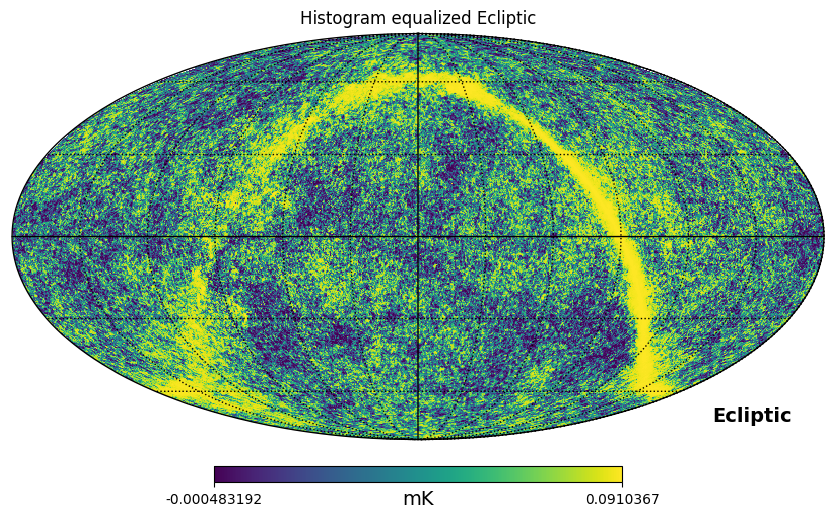

In [4]:
wmap_map_I = hp.read_map("maps/LFI_SkyMap_070-BPassCorrected-field-IQU_1024_R3.00_full.fits")
print(wmap_map_I)
hp.mollview(
    wmap_map_I,
    coord=["G", "E"],
    title="Histogram equalized Ecliptic",
    unit="mK",
    norm="hist")
hp.graticule()


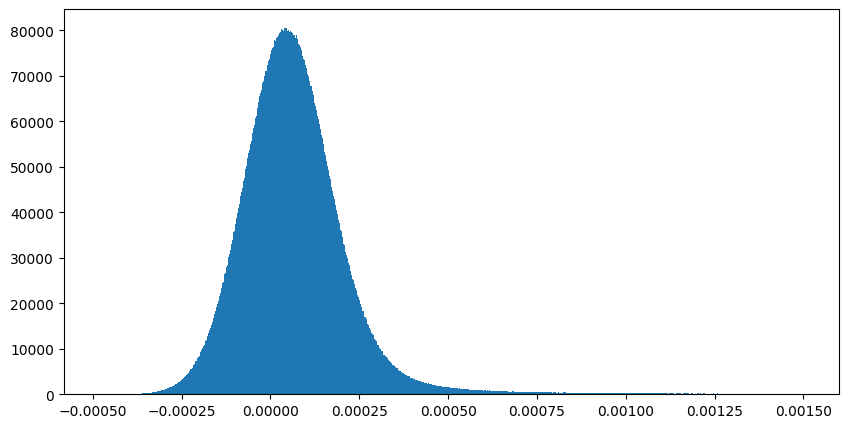

In [5]:
plt.figure(figsize=(10, 5))
plt.hist(wmap_map_I, bins=1000,range=(-0.000483192,0.0015));

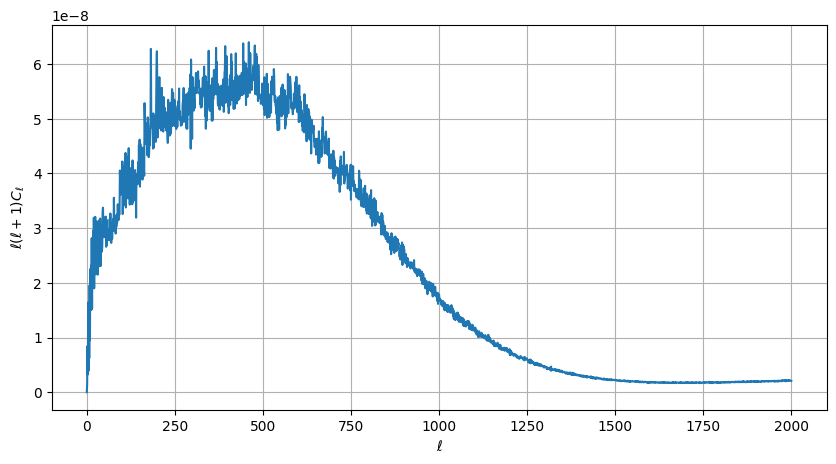

In [6]:
LMAX = 2000
cl = hp.anafast(wmap_map_I, lmax=LMAX)
ell = np.arange(len(cl))
plt.figure(figsize=(10, 5))
plt.plot(ell, (ell * (ell + 1) * cl)/(2*np.pi))
plt.xlabel("$\ell$")
plt.ylabel("$\ell(\ell+1)C_{\ell}$")
plt.grid()

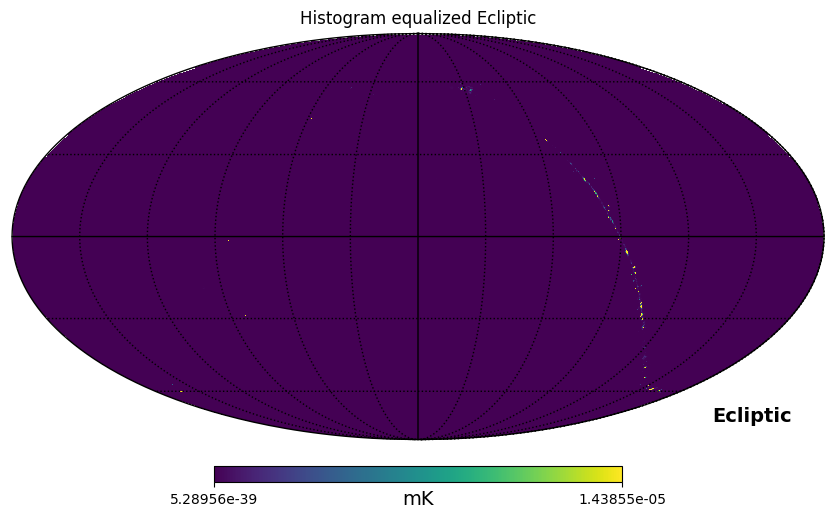

In [7]:
rho= np.pi/15*(wmap_map_I)**4
hp.mollview(
    rho,
    coord=["G", "E"],
    title="Histogram equalized Ecliptic",
    unit="mK",
    norm="hist")
hp.graticule()

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import sys, platform, os
import matplotlib
from matplotlib import pyplot as plt
import numpy as np
import camb
from camb import model, initialpower
print('Using CAMB %s installed at %s'%(camb.__version__,os.path.dirname(camb.__file__)))

Using CAMB 1.5.9 installed at /root/Yago/.venv/lib/python3.10/site-packages/camb


In [3]:
#Set up a new set of parameters for CAMB
#The defaults give one massive neutrino and helium set using BBN consistency
pars = camb.set_params(H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.06,  
                       As=2e-9, ns=0.965, halofit_version='mead', lmax=3000)

In [4]:
results = camb.get_results(pars)

In [5]:
powers =results.get_cmb_power_spectra(pars, CMB_unit='muK')
for name in powers: print(name)

total
unlensed_scalar
unlensed_total
lensed_scalar
tensor
lens_potential


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


(3051, 4)


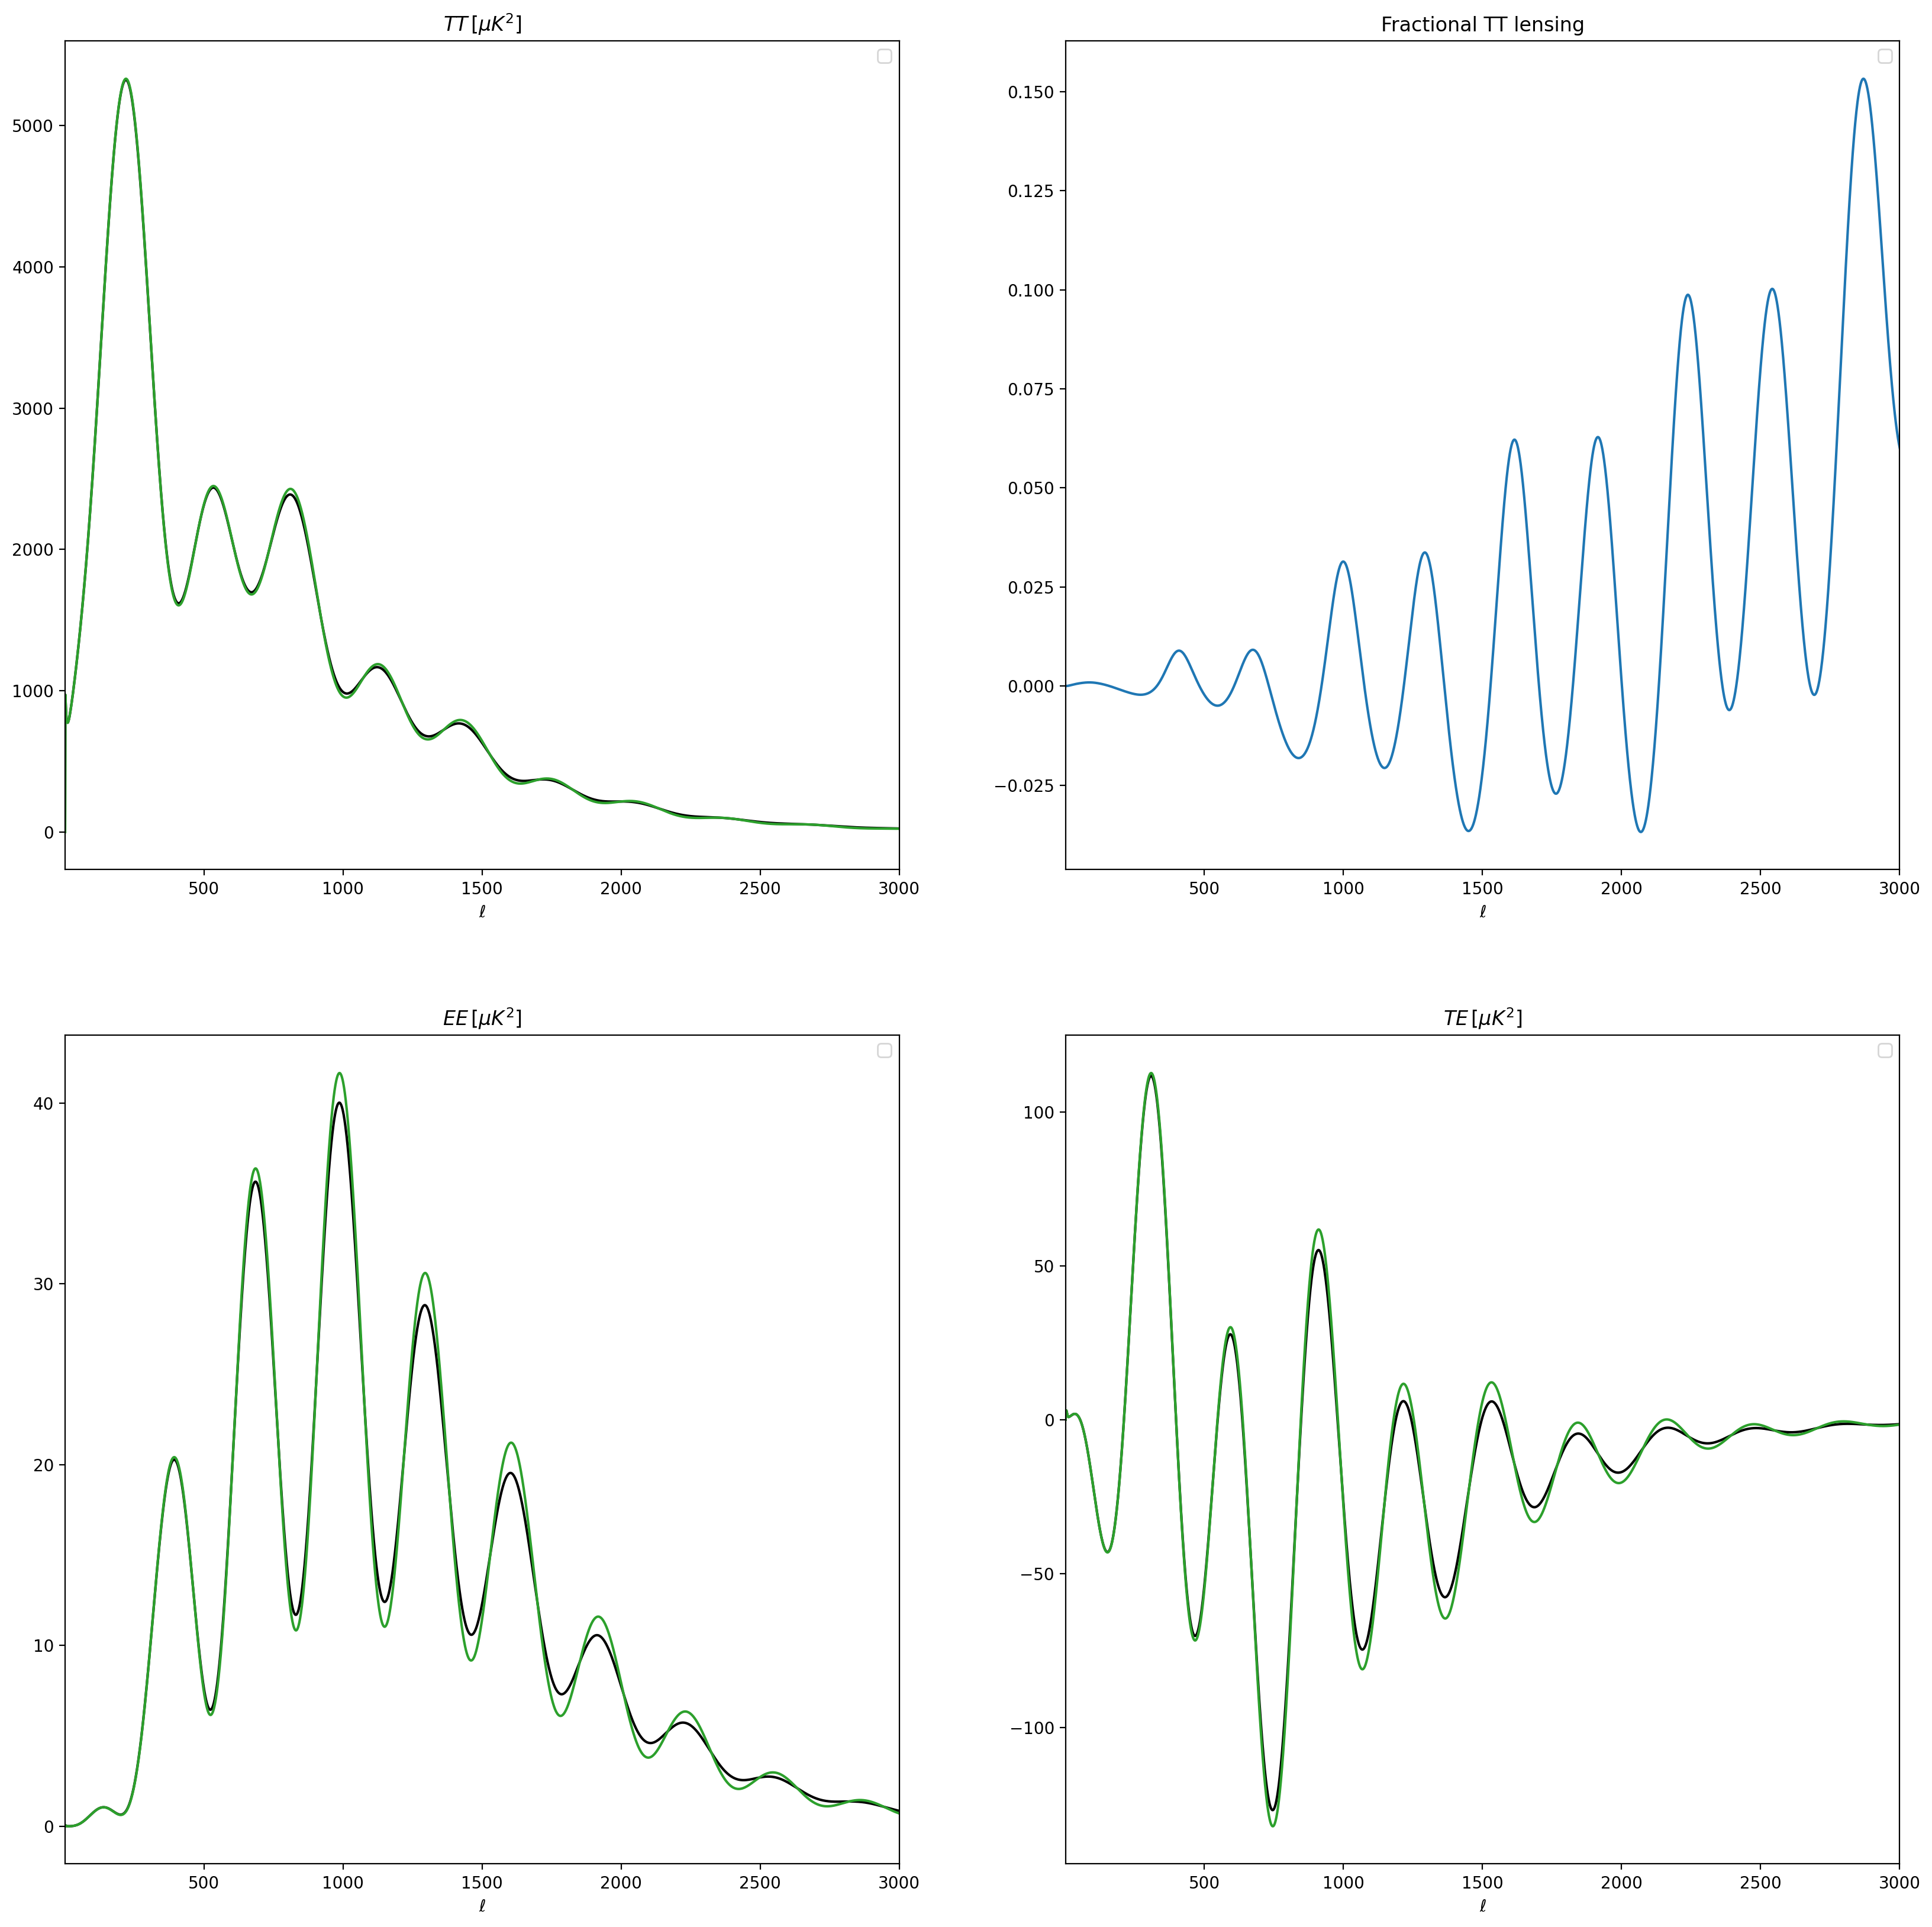

In [8]:
totCL=powers['total']
unlensedCL=powers['unlensed_scalar']
print(totCL.shape)
#Python CL arrays are all zero based (starting at L=0), Note L=0,1 entries will be zero by default.
#The different CL are always in the order TT, EE, BB, TE (with BB=0 for unlensed scalar results).
ls = np.arange(totCL.shape[0])
fig, ax = plt.subplots(2,2, figsize = (20,20))
ax[0,0].plot(ls,totCL[:,0], color='k')
ax[0,0].plot(ls,unlensedCL[:,0], color='C2')
ax[0,0].set_title(r'$TT\, [\mu K^2]$')
ax[0,1].plot(ls[2:], 1-unlensedCL[2:,0]/totCL[2:,0]);
ax[0,1].set_title(r'Fractional TT lensing')
ax[1,0].plot(ls,totCL[:,1], color='k')
ax[1,0].plot(ls,unlensedCL[:,1], color='C2')
ax[1,0].set_title(r'$EE\, [\mu K^2]$')
ax[1,1].plot(ls,totCL[:,3], color='k')
ax[1,1].plot(ls,unlensedCL[:,3], color='C2')
ax[1,1].set_title(r'$TE\, [\mu K^2]$');
for ax in ax.reshape(-1): 
    ax.set_xlim([2,3000])
    ax.set_xlabel(r'$\ell$');
    ax.legend()